# Implementing Optimization Algorithms with TensorFlow on MNIST Dataset

This notebook demonstrates how to implement different optimization algorithms using TensorFlow on the MNIST dataset. We'll use a simple fully connected neural network (not a CNN) for the task of classifying handwritten digits from the MNIST dataset.

## Setup

We begin by importing the necessary libraries and loading the MNIST dataset.

In [1]:
# Importing required libraries
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [2]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images to range [0, 1]
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten the images to 1D vectors (28*28 = 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

# Convert labels to categorical
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)


In [3]:
# Define the model
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),  # Hidden layer
    layers.Dense(10, activation='softmax')  # Output layer (10 classes)
])

# Compile the model
model.compile(optimizer='sgd',  # We'll change this optimizer in the next sections
              loss='categorical_crossentropy',
              metrics=['accuracy'])


c:\Users\Hait\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# 1. Using Stochastic Gradient Descent (SGD)
We'll start by training the model with the standard SGD optimization algorithm.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8366 - loss: 0.6489 - val_accuracy: 0.9054 - val_loss: 0.3541
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9069 - loss: 0.3332 - val_accuracy: 0.9205 - val_loss: 0.2889
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9196 - loss: 0.2831 - val_accuracy: 0.9294 - val_loss: 0.2554
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9295 - loss: 0.2529 - val_accuracy: 0.9344 - val_loss: 0.2312
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9354 - loss: 0.2301 - val_accuracy: 0.9385 - val_loss: 0.2139


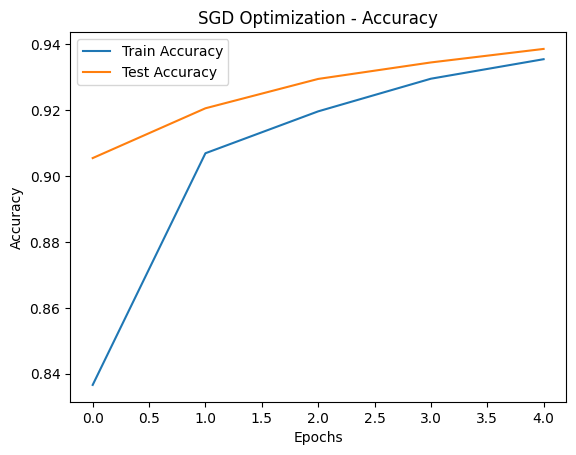

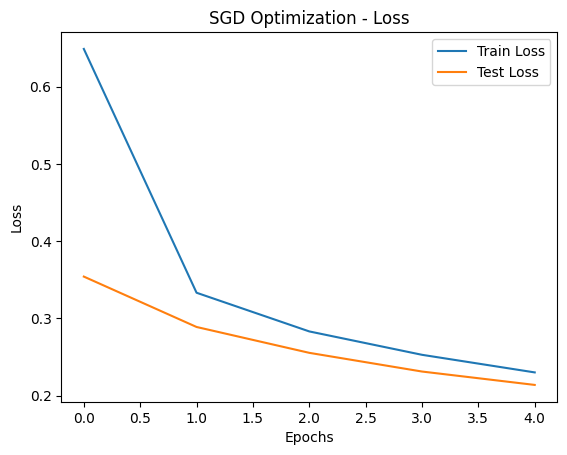

In [4]:
# Train the model using SGD
history_sgd = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Plot the accuracy and loss
plt.plot(history_sgd.history['accuracy'], label='Train Accuracy')
plt.plot(history_sgd.history['val_accuracy'], label='Test Accuracy')
plt.title('SGD Optimization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_sgd.history['loss'], label='Train Loss')
plt.plot(history_sgd.history['val_loss'], label='Test Loss')
plt.title('SGD Optimization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 2. Using Adam Optimizer
Now, we'll use the Adam optimizer, which adapts the learning rate based on the momentums of the gradient.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9266 - loss: 0.2571 - val_accuracy: 0.9580 - val_loss: 0.1389
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9666 - loss: 0.1111 - val_accuracy: 0.9690 - val_loss: 0.0977
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9770 - loss: 0.0775 - val_accuracy: 0.9730 - val_loss: 0.0858
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9822 - loss: 0.0585 - val_accuracy: 0.9770 - val_loss: 0.0751
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9859 - loss: 0.0450 - val_accuracy: 0.9780 - val_loss: 0.0690


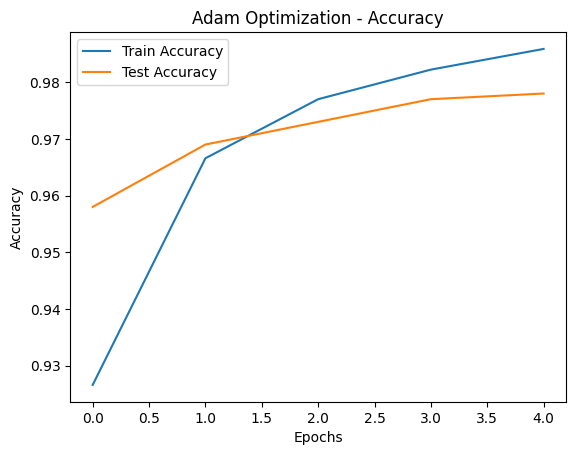

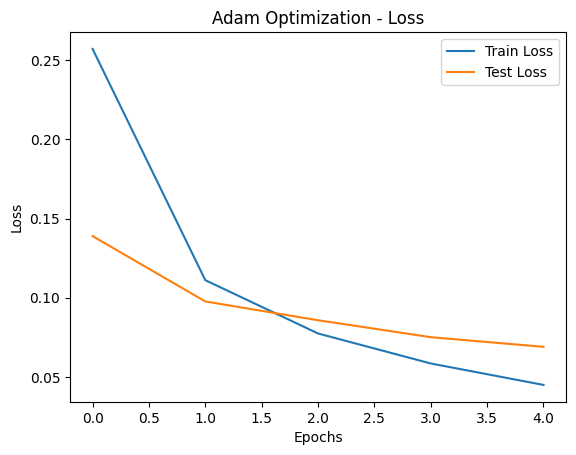

In [5]:
# Rebuild the model to reset weights
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

# Compile the model with Adam optimizer
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using Adam
history_adam = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Plot the accuracy and loss
plt.plot(history_adam.history['accuracy'], label='Train Accuracy')
plt.plot(history_adam.history['val_accuracy'], label='Test Accuracy')
plt.title('Adam Optimization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_adam.history['loss'], label='Train Loss')
plt.plot(history_adam.history['val_loss'], label='Test Loss')
plt.title('Adam Optimization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 3. Using RMSprop Optimizer
Next, we implement the RMSprop optimizer, which divides the learning rate by an exponentially decaying average of squared gradients.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9252 - loss: 0.2637 - val_accuracy: 0.9597 - val_loss: 0.1399
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9653 - loss: 0.1187 - val_accuracy: 0.9700 - val_loss: 0.1036
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9742 - loss: 0.0854 - val_accuracy: 0.9744 - val_loss: 0.0832
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9806 - loss: 0.0670 - val_accuracy: 0.9757 - val_loss: 0.0875
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9837 - loss: 0.0550 - val_accuracy: 0.9770 - val_loss: 0.0793


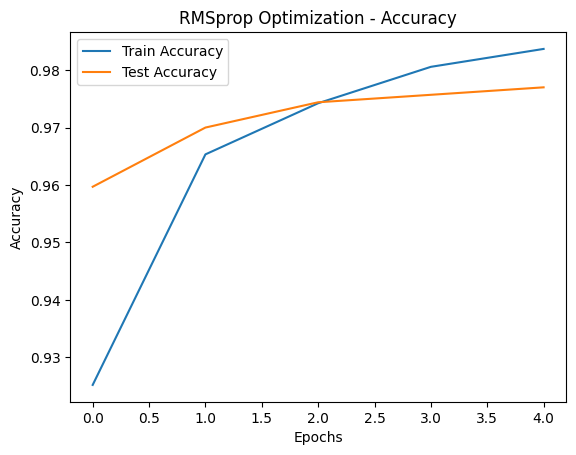

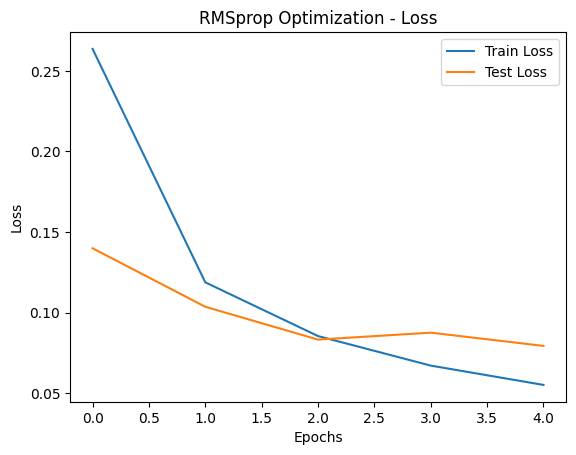

In [6]:
# Rebuild the model to reset weights
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

# Compile the model with RMSprop optimizer
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using RMSprop
history_rmsprop = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Plot the accuracy and loss
plt.plot(history_rmsprop.history['accuracy'], label='Train Accuracy')
plt.plot(history_rmsprop.history['val_accuracy'], label='Test Accuracy')
plt.title('RMSprop Optimization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_rmsprop.history['loss'], label='Train Loss')
plt.plot(history_rmsprop.history['val_loss'], label='Test Loss')
plt.title('RMSprop Optimization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 4. Using Adagrad Optimizer
Adagrad is an adaptive learning rate optimizer that adjusts the learning rate for each parameter based on its history of gradients.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7317 - loss: 1.1592 - val_accuracy: 0.8520 - val_loss: 0.6816
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8577 - loss: 0.6043 - val_accuracy: 0.8802 - val_loss: 0.5078
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8767 - loss: 0.4948 - val_accuracy: 0.8922 - val_loss: 0.4408
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8862 - loss: 0.4430 - val_accuracy: 0.8985 - val_loss: 0.4034
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.8922 - loss: 0.4115 - val_accuracy: 0.9044 - val_loss: 0.3797


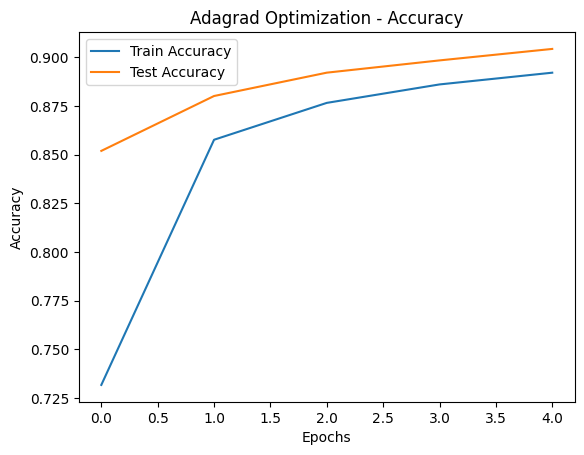

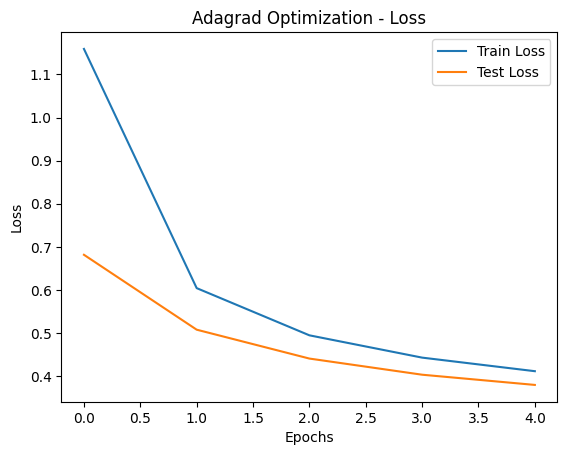

In [7]:
# Rebuild the model to reset weights
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

# Compile the model with Adagrad optimizer
model.compile(optimizer='adagrad',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using Adagrad
history_adagrad = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Plot the accuracy and loss
plt.plot(history_adagrad.history['accuracy'], label='Train Accuracy')
plt.plot(history_adagrad.history['val_accuracy'], label='Test Accuracy')
plt.title('Adagrad Optimization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_adagrad.history['loss'], label='Train Loss')
plt.plot(history_adagrad.history['val_loss'], label='Test Loss')
plt.title('Adagrad Optimization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


# 5. Using Nadam Optimizer
Finally, we use the Nadam optimizer, a variant of Adam with Nesterov momentum.

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9268 - loss: 0.2595 - val_accuracy: 0.9568 - val_loss: 0.1408
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9672 - loss: 0.1137 - val_accuracy: 0.9691 - val_loss: 0.1010
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9760 - loss: 0.0787 - val_accuracy: 0.9741 - val_loss: 0.0797
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9817 - loss: 0.0586 - val_accuracy: 0.9737 - val_loss: 0.0790
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9868 - loss: 0.0444 - val_accuracy: 0.9765 - val_loss: 0.0773


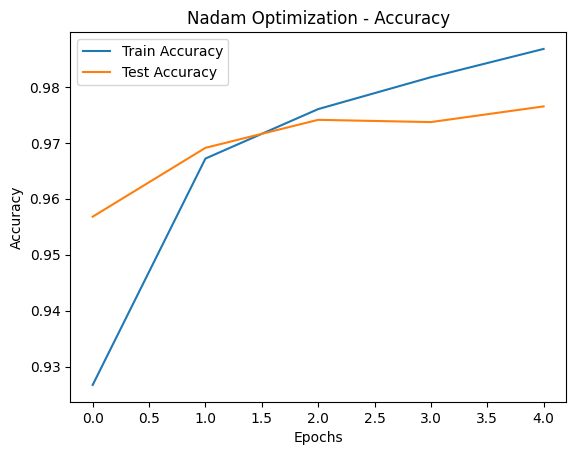

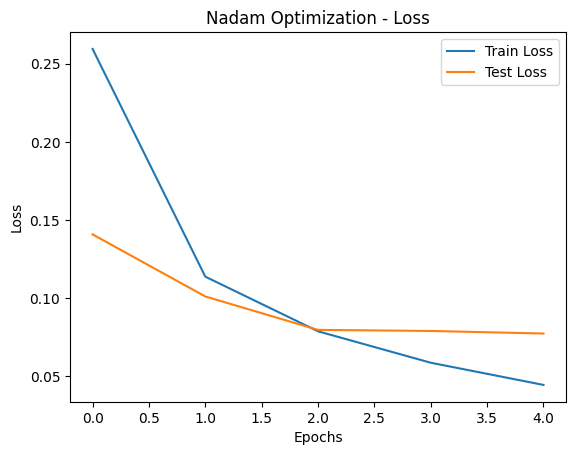

In [8]:
# Rebuild the model to reset weights
model = models.Sequential([
    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(10, activation='softmax')
])

# Compile the model with Nadam optimizer
model.compile(optimizer='nadam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model using Nadam
history_nadam = model.fit(x_train, y_train, epochs=5, batch_size=32, validation_data=(x_test, y_test))

# Plot the accuracy and loss
plt.plot(history_nadam.history['accuracy'], label='Train Accuracy')
plt.plot(history_nadam.history['val_accuracy'], label='Test Accuracy')
plt.title('Nadam Optimization - Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history_nadam.history['loss'], label='Train Loss')
plt.plot(history_nadam.history['val_loss'], label='Test Loss')
plt.title('Nadam Optimization - Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()
